# 📊 Bitcoin Market Sentiment & Trader Behavior Analysis
### Hyperliquid Trader Data × Fear & Greed Index (2023–2025)

**Objective:** Analyze how Bitcoin market sentiment (Fear vs Greed) affects trader behavior and performance.  
**Datasets:**
- `fear_greed_index.csv` — Daily Bitcoin Fear & Greed classifications
- `historical_data.csv` — Hyperliquid perpetual futures trade-level data (211K rows, 32 traders)

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

FEAR_COLOR   = '#e74c3c'   # red
GREED_COLOR  = '#2ecc71'   # green
NEUTRAL_COLOR = '#95a5a6'  # grey

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 2. Load Datasets

In [2]:
# ── Load Fear & Greed Index ──────────────────────────────────────────────────
fg_raw = pd.read_csv('fear_greed_index.csv')
print(f'Fear & Greed Index → {fg_raw.shape[0]:,} rows × {fg_raw.shape[1]} columns')
display(fg_raw.head(3))

# ── Load Trader Data ─────────────────────────────────────────────────────────
trades_raw = pd.read_csv('historical_data.csv')
print(f'\nHyperliquid Trader Data → {trades_raw.shape[0]:,} rows × {trades_raw.shape[1]} columns')
display(trades_raw.head(3))

Fear & Greed Index → 2,644 rows × 4 columns


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03



Hyperliquid Trader Data → 211,224 rows × 16 columns


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


---
## 3. Data Exploration

In [3]:
# ═══════════════════════════════════════════════════════════════════
# 3.1  Fear & Greed — Shape, Missing Values, Duplicates
# ═══════════════════════════════════════════════════════════════════
print('=' * 50)
print('FEAR & GREED INDEX — Exploration')
print('=' * 50)
print(f'Shape : {fg_raw.shape}')
print(f'\nMissing values:\n{fg_raw.isnull().sum()}')
print(f'\nDuplicates : {fg_raw.duplicated().sum()}')
print(f'\nClassification distribution:\n{fg_raw["classification"].value_counts()}')
display(fg_raw.describe())

FEAR & GREED INDEX — Exploration
Shape : (2644, 4)

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates : 0

Classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [24]:
# ═══════════════════════════════════════════════════════════════════
# 3.2  Trader Data — Shape, Missing Values, Duplicates
# ═══════════════════════════════════════════════════════════════════
print('=' * 50)
print('HYPERLIQUID TRADER DATA — Exploration')
print('=' * 50)
print(f'Shape : {trades_raw.shape}')
print(f'\nMissing values per column:')
print(f"\nMissing values:\n{trades.isnull().sum().to_string()}")
print(f'\nDuplicates : {trades_raw.duplicated().sum()}')
print(f'\nUnique traders : {trades_raw["Account"].nunique()}')
print(f'Unique coins   : {trades_raw["Coin"].nunique()}')
print(f'\nDirection distribution:\n{trades_raw["Direction"].value_counts()}')
display(trades_raw[['Execution Price','Size Tokens','Size USD',
                     'Closed PnL','Fee']].describe())

HYPERLIQUID TRADER DATA — Exploration
Shape : (211224, 16)

Missing values per column:

Missing values:
account             0
coin                0
exec_price          0
size_tokens         0
size_usd            0
side                0
Timestamp IST       0
start_position      0
direction           0
closed_pnl          0
Transaction Hash    0
Order ID            0
Crossed             0
fee                 0
Trade ID            0
Timestamp           0
datetime            0
date                0

Duplicates : 0

Unique traders : 32
Unique coins   : 246

Direction distribution:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement            

,Execution Price,Size Tokens,Size USD,Closed PnL,Fee
count,211224.000000,2.112240e+05,2.112240e+05,211224.000000,211224.000000
mean,11414.723350,4.623365e+03,5.639451e+03,48.749001,1.163967
std,29447.654868,1.042729e+05,3.657514e+04,919.164828,6.758854
min,0.000005,8.740000e-07,0.000000e+00,-117990.104100,-1.175712
25%,4.854700,2.940000e+00,1.937900e+02,0.000000,0.016121
50%,18.280000,3.200000e+01,5.970450e+02,0.000000,0.089578
75%,101.580000,1.879025e+02,2.058960e+03,5.792797,0.393811
max,109004.000000,1.582244e+07,3.921431e+06,135329.090100,837.471593


---
## 4. Data Cleaning & Timestamp Alignment

In [5]:
# ═══════════════════════════════════════════════════════════════════
# 4.1  Parse timestamps and extract date keys for joining
# ═══════════════════════════════════════════════════════════════════

# --- Fear & Greed ---
fg = fg_raw.copy()
fg['date'] = pd.to_datetime(fg['date'])          # already YYYY-MM-DD

# Collapse 5 categories → 3 (Fear / Neutral / Greed) for cleaner analysis
fg['sentiment'] = fg['classification'].replace({
    'Extreme Fear' : 'Fear',
    'Fear'         : 'Fear',
    'Neutral'      : 'Neutral',
    'Greed'        : 'Greed',
    'Extreme Greed': 'Greed',
})

# --- Trader Data ---
trades = trades_raw.copy()

# Parse 'DD-MM-YYYY HH:MM' format → datetime, then extract date
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M',
                                    errors='coerce')
trades['date'] = trades['datetime'].dt.normalize()   # midnight-aligned date

# Drop rows where date parsing failed
n_before = len(trades)
trades = trades.dropna(subset=['date'])
print(f'Rows dropped (unparseable timestamps): {n_before - len(trades)}')

# Rename columns for consistency
trades = trades.rename(columns={
    'Account'        : 'account',
    'Coin'           : 'coin',
    'Execution Price': 'exec_price',
    'Size Tokens'    : 'size_tokens',
    'Size USD'       : 'size_usd',
    'Side'           : 'side',
    'Start Position' : 'start_position',
    'Direction'      : 'direction',
    'Closed PnL'     : 'closed_pnl',
    'Fee'            : 'fee',
})

print(f'\nTrade date range : {trades["date"].min().date()}  →  {trades["date"].max().date()}')
print(f'F&G  date range  : {fg["date"].min().date()}  →  {fg["date"].max().date()}')
print('\n✅ Timestamps parsed and aligned.')

Rows dropped (unparseable timestamps): 0

Trade date range : 2023-05-01  →  2025-05-01
F&G  date range  : 2018-02-01  →  2025-05-02

✅ Timestamps parsed and aligned.


---
## 5. Merge Sentiment with Trader Data

In [27]:
# ═══════════════════════════════════════════════════════════════════
# 5.1  Left-join trades on Fear & Greed by date
# ═══════════════════════════════════════════════════════════════════

merged = trades.merge(
    fg[['date', 'sentiment', 'value']].rename(columns={'value': 'fg_score'}),
    on='date',
    how='inner'     # keep only dates that exist in both datasets
)

print(f'Rows after merge : {len(merged):,}')
print(f'Date range covered : {merged["date"].min().date()} → {merged["date"].max().date()}')
print(f'\nSentiment distribution in merged dataset:')
print(merged['sentiment'].value_counts())

print('\n✅ Merge complete.')
display(merged[['date','account','coin','exec_price','size_usd',
                'direction','closed_pnl','sentiment','fg_score']].head(5))

Rows after merge : 211,218
Date range covered : 2023-05-01 → 2025-05-01

Sentiment distribution in merged dataset:
sentiment
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64

✅ Merge complete.


,date,account,coin,exec_price,size_usd,direction,closed_pnl,sentiment,fg_score
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,7872.16,Buy,0.0,Greed,80
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,127.68,Buy,0.0,Greed,80
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,1150.63,Buy,0.0,Greed,80
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,1142.04,Buy,0.0,Greed,80
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,69.75,Buy,0.0,Greed,80


---
## 6. Feature Engineering & Metric Construction

In [28]:
# ═══════════════════════════════════════════════════════════════════
# 6.1  Trade-level features
# ═══════════════════════════════════════════════════════════════════

# Profitable trade flag
merged['is_winner'] = (merged['closed_pnl'] > 0).astype(int)

# Net PnL after fees
merged['net_pnl'] = merged['closed_pnl'] - merged['fee']

# Leverage proxy: Size USD / |Start Position × Exec Price|  (where start_position != 0)
# For rows with no prior position (start_position == 0), leverage is undefined → use size_usd quartile rank
mask = merged['start_position'].abs() > 0
merged.loc[mask, 'leverage'] = (
    merged.loc[mask, 'size_usd'].abs() /
    (merged.loc[mask, 'start_position'].abs() * merged.loc[mask, 'exec_price'])
).clip(upper=200)   # cap extreme outliers at 200×
merged.loc[~mask, 'leverage'] = np.nan

# Broad direction: Long / Short / Other
long_dirs  = {'Open Long', 'Close Short', 'Long > Short'}
short_dirs = {'Open Short', 'Close Long', 'Short > Long'}
merged['broad_side'] = np.where(merged['direction'].isin(long_dirs), 'Long',
                        np.where(merged['direction'].isin(short_dirs), 'Short', 'Other'))

print('Trade-level features added: is_winner, net_pnl, leverage, broad_side')

# ═══════════════════════════════════════════════════════════════════
# 6.2  Daily metrics
# ═══════════════════════════════════════════════════════════════════

# — Daily PnL per trader
daily_pnl = (
    merged.groupby(['date','account','sentiment'])
    .agg(daily_pnl=('net_pnl','sum'),
         trade_count=('net_pnl','count'))
    .reset_index()
)

# — Win rate: fraction of trades with positive PnL
win_rate = (
    merged.groupby(['date','account','sentiment'])
    .agg(win_rate=('is_winner','mean'))
    .reset_index()
)

# — Average trade size per day per sentiment
avg_size = (
    merged.groupby(['date','sentiment'])
    .agg(avg_size_usd=('size_usd','mean'),
         median_size_usd=('size_usd','median'))
    .reset_index()
)

# — Leverage distribution per sentiment
lev_dist = merged.dropna(subset=['leverage'])

# — Number of trades per day
trades_per_day = (
    merged.groupby(['date','sentiment'])
    .size().reset_index(name='n_trades')
)

# — Long/Short ratio per day
ls_daily = (
    merged[merged['broad_side'].isin(['Long','Short'])]
    .groupby(['date','sentiment','broad_side'])
    .size().unstack('broad_side', fill_value=0)
    .assign(ls_ratio=lambda d: d['Long'] / (d['Short'] + 1e-9))
    .reset_index()
)

print('\nDaily metrics computed: daily_pnl, win_rate, avg_size, lev_dist, trades_per_day, ls_ratio')
print(f'  daily_pnl   : {daily_pnl.shape}')
print(f'  trades/day  : {trades_per_day.shape}')
print(f'  L/S daily   : {ls_daily.shape}')

Trade-level features added: is_winner, net_pnl, leverage, broad_side

Daily metrics computed: daily_pnl, win_rate, avg_size, lev_dist, trades_per_day, ls_ratio
  daily_pnl   : (2340, 5)
  trades/day  : (479, 3)
  L/S daily   : (461, 5)


In [29]:
# ═══════════════════════════════════════════════════════════════════
# 6.3  Trader-level segmentation
# ═══════════════════════════════════════════════════════════════════

trader_profile = (
    merged.groupby('account')
    .agg(
        total_trades    = ('net_pnl', 'count'),
        total_pnl       = ('net_pnl', 'sum'),
        win_trades      = ('is_winner', 'sum'),
        avg_size_usd    = ('size_usd', 'mean'),
        median_leverage = ('leverage', 'median'),
        std_daily_pnl   = ('net_pnl', 'std'),
    )
    .reset_index()
)

trader_profile['win_rate'] = trader_profile['win_trades'] / trader_profile['total_trades']

# ─── Segment 1: High vs Low Leverage ────────────────────────────────────────
lev_median = trader_profile['median_leverage'].median()
trader_profile['lev_segment'] = np.where(
    trader_profile['median_leverage'] >= lev_median, 'High Leverage', 'Low Leverage'
)

# ─── Segment 2: Frequent vs Infrequent Traders ──────────────────────────────
freq_median = trader_profile['total_trades'].median()
trader_profile['freq_segment'] = np.where(
    trader_profile['total_trades'] >= freq_median, 'Frequent', 'Infrequent'
)

# ─── Segment 3: Consistent vs Inconsistent Winners ──────────────────────────
# Consistent = high win rate AND low std of daily PnL (relative to mean |pnl|)
wr_thresh  = trader_profile['win_rate'].quantile(0.60)
std_thresh = trader_profile['std_daily_pnl'].quantile(0.40)
trader_profile['consistency'] = np.where(
    (trader_profile['win_rate'] >= wr_thresh) &
    (trader_profile['std_daily_pnl'] <= std_thresh),
    'Consistent Winner',
    'Inconsistent'
)

print('Trader profiles built:')
print(f'  Leverage segments  : {trader_profile["lev_segment"].value_counts().to_dict()}')
print(f'  Frequency segments : {trader_profile["freq_segment"].value_counts().to_dict()}')
print(f'  Consistency segments : {trader_profile["consistency"].value_counts().to_dict()}')
display(trader_profile.sort_values('total_pnl', ascending=False).head(5))

Trader profiles built:
  Leverage segments  : {'Low Leverage': 16, 'High Leverage': 16}
  Frequency segments : {'Frequent': 16, 'Infrequent': 16}
  Consistency segments : {'Inconsistent': 26, 'Consistent Winner': 6}


,account,total_trades,total_pnl,win_trades,avg_size_usd,median_leverage,std_daily_pnl,win_rate,lev_segment,freq_segment,consistency
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.127387e+06,4967,3837.885375,0.010876,1373.777917,0.337134,High Leverage,Frequent,Inconsistent
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.592825e+06,1373,16159.576734,0.002606,4690.764320,0.359612,Low Leverage,Frequent,Inconsistent
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.315671e+05,9909,3210.472831,0.000558,565.375876,0.467582,Low Leverage,Frequent,Inconsistent
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.227277e+05,17208,1844.211886,0.007285,264.085785,0.428230,Low Leverage,Frequent,Inconsistent
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,7.639979e+05,4909,34396.580284,0.002813,633.686966,0.401193,Low Leverage,Frequent,Inconsistent


---
## 7. Analysis — Sentiment vs. Trader Performance & Behavior

In [30]:
# ═══════════════════════════════════════════════════════════════════
# 7.1  Does trader performance differ between Fear vs Greed days?
# ═══════════════════════════════════════════════════════════════════

perf_by_sentiment = (
    merged.groupby('sentiment')
    .agg(
        mean_pnl      = ('net_pnl',   'mean'),
        median_pnl    = ('net_pnl',   'median'),
        total_pnl     = ('net_pnl',   'sum'),
        win_rate      = ('is_winner', 'mean'),
        n_trades      = ('net_pnl',   'count'),
    )
    .reset_index()
)
perf_by_sentiment['win_rate_pct'] = (perf_by_sentiment['win_rate'] * 100).round(1)

print('═' * 55)
print('PERFORMANCE BY SENTIMENT')
print('═' * 55)
display(perf_by_sentiment)

═══════════════════════════════════════════════════════
PERFORMANCE BY SENTIMENT
═══════════════════════════════════════════════════════


,sentiment,mean_pnl,median_pnl,total_pnl,win_rate,n_trades,win_rate_pct
0,Fear,47.814315,-0.005821,3.979920e+06,0.407871,83237,40.8
1,Greed,52.884116,-0.005041,4.775171e+06,0.420311,90295,42.0
2,Neutral,33.262920,-0.007516,1.253546e+06,0.396991,37686,39.7


In [10]:
# ═══════════════════════════════════════════════════════════════════
# 7.2  Do traders CHANGE BEHAVIOR based on sentiment?
# ═══════════════════════════════════════════════════════════════════

behavior_by_sentiment = (
    merged.groupby('sentiment')
    .agg(
        avg_trade_size  = ('size_usd',   'mean'),
        median_leverage = ('leverage',   'median'),
        trades_per_day  = ('net_pnl',    'count'),
        long_ratio      = ('broad_side', lambda x: (x == 'Long').mean()),
    )
    .reset_index()
)
behavior_by_sentiment['long_pct']  = (behavior_by_sentiment['long_ratio']  * 100).round(1)

print('═' * 55)
print('TRADING BEHAVIOR BY SENTIMENT')
print('═' * 55)
display(behavior_by_sentiment)

═══════════════════════════════════════════════════════
TRADING BEHAVIOR BY SENTIMENT
═══════════════════════════════════════════════════════


,sentiment,avg_trade_size,median_leverage,trades_per_day,long_ratio,long_pct
0,Fear,7182.011019,0.007105,83237,0.446748,44.7
1,Neutral,4782.732661,0.011515,37686,0.426869,42.7
2,Greed,4574.424490,0.018283,90295,0.361991,36.2


---
## 8. Visualizations

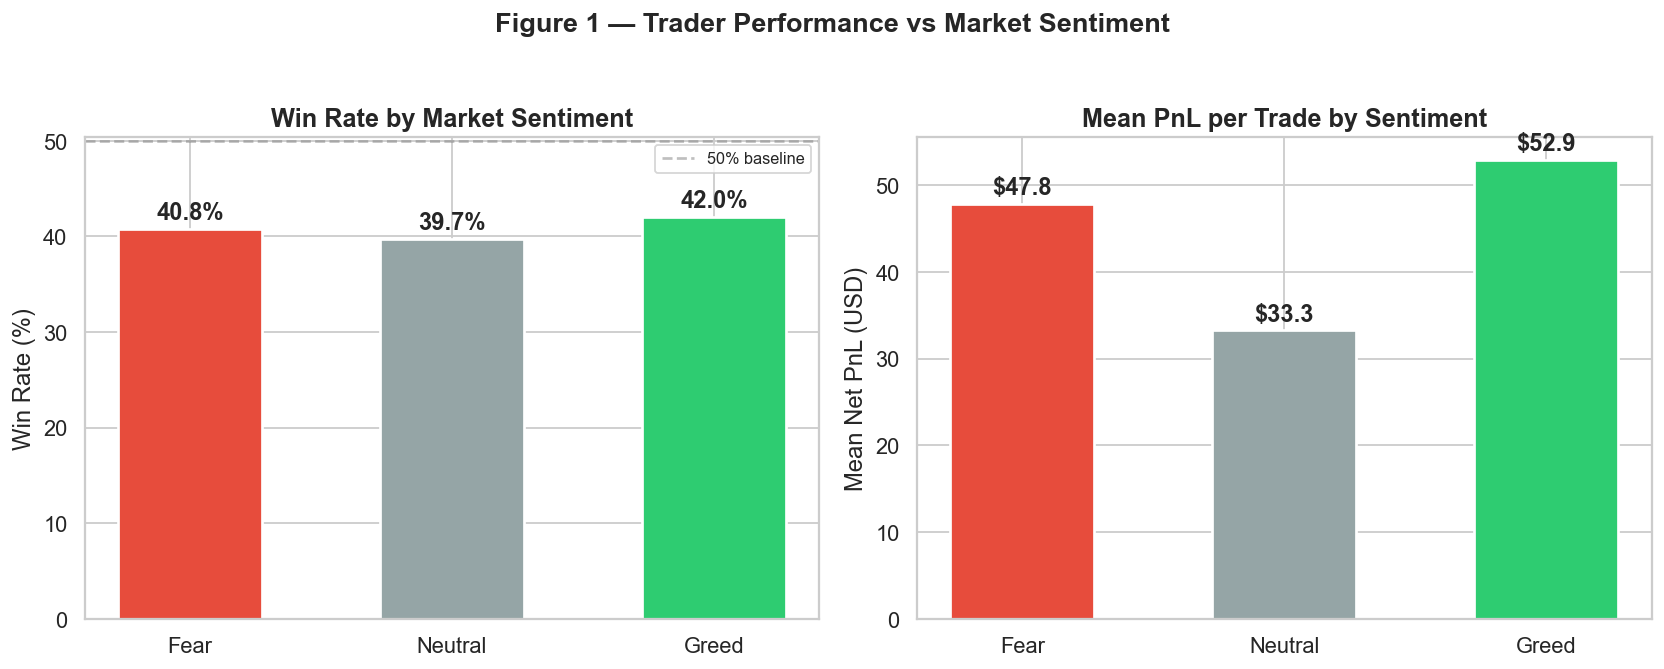

Figure 1 saved.


In [11]:
# ═══════════════════════════════════════════════════════════════════
# VIZ 1 — Win Rate & Mean PnL by Sentiment (side-by-side bar)
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette   = {'Fear': FEAR_COLOR, 'Neutral': NEUTRAL_COLOR, 'Greed': GREED_COLOR}

# — Win Rate —
ax = axes[0]
bars = ax.bar(
    perf_by_sentiment['sentiment'],
    perf_by_sentiment['win_rate_pct'],
    color=[palette[s] for s in perf_by_sentiment['sentiment']],
    edgecolor='white', linewidth=1.5, width=0.55
)
for bar, val in zip(bars, perf_by_sentiment['win_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Win Rate by Market Sentiment', fontsize=14, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, perf_by_sentiment['win_rate_pct'].max() * 1.2)
ax.axhline(50, linestyle='--', color='gray', alpha=0.5, label='50% baseline')
ax.legend(fontsize=9)

# — Mean PnL per trade —
ax2 = axes[1]
bars2 = ax2.bar(
    perf_by_sentiment['sentiment'],
    perf_by_sentiment['mean_pnl'],
    color=[palette[s] for s in perf_by_sentiment['sentiment']],
    edgecolor='white', linewidth=1.5, width=0.55
)
for bar, val in zip(bars2, perf_by_sentiment['mean_pnl']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.5 if val >= 0 else -5),
             f'${val:,.1f}', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Mean PnL per Trade by Sentiment', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Net PnL (USD)')
ax2.axhline(0, linestyle='-', color='black', linewidth=0.8)

plt.suptitle('Figure 1 — Trader Performance vs Market Sentiment',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig1_performance_by_sentiment.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

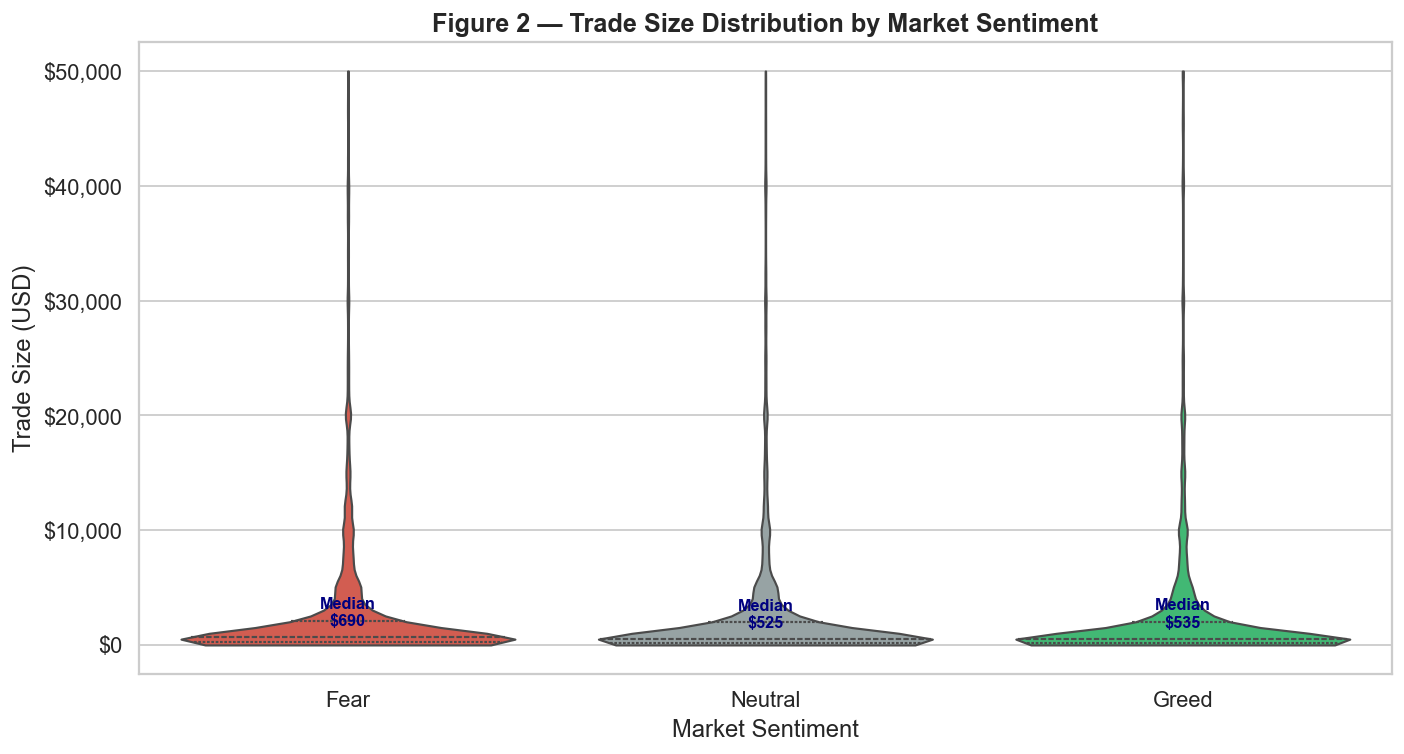

Figure 2 saved.


In [12]:
# ═══════════════════════════════════════════════════════════════════
# VIZ 2 — Trade Size Distribution by Sentiment (violin + strip)
# ═══════════════════════════════════════════════════════════════════

# Cap extreme outliers for clean display
size_cap = merged['size_usd'].quantile(0.98)
plot_df  = merged[merged['size_usd'] <= size_cap]

fig, ax = plt.subplots(figsize=(11, 6))

sns.violinplot(
    data=plot_df, x='sentiment', y='size_usd',
    palette=palette, order=sent_order,
    inner='quartile', cut=0, linewidth=1.2, ax=ax
)
ax.set_title('Figure 2 — Trade Size Distribution by Market Sentiment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Trade Size (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate medians
for i, sent in enumerate(sent_order):
    med = plot_df[plot_df['sentiment'] == sent]['size_usd'].median()
    ax.text(i, med + size_cap * 0.02, f'Median\n${med:,.0f}',
            ha='center', fontsize=9, color='navy', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_trade_size_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

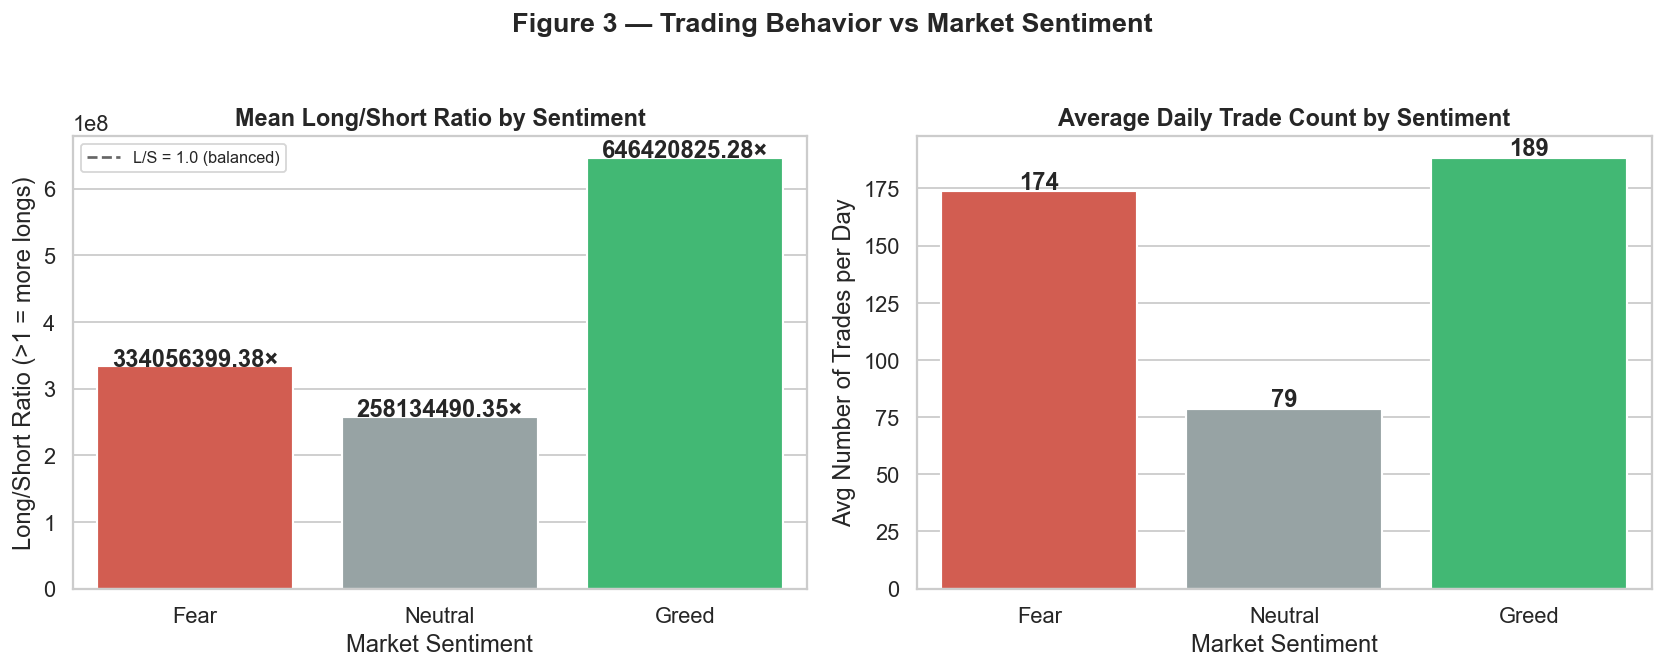

Figure 3 saved.


In [13]:
# ═══════════════════════════════════════════════════════════════════
# VIZ 3 — Long/Short Ratio & Trade Frequency by Sentiment
# ═══════════════════════════════════════════════════════════════════

ls_summary = ls_daily.groupby('sentiment').agg(
    mean_ls_ratio = ('ls_ratio', 'mean'),
).reset_index()

tpd_summary = trades_per_day.groupby('sentiment').agg(
    mean_trades = ('n_trades', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Long/Short Ratio —
ax = axes[0]
sns.barplot(data=ls_summary, x='sentiment', y='mean_ls_ratio',
            palette=palette, order=sent_order, ax=ax,
            edgecolor='white', linewidth=1.2)
ax.axhline(1.0, linestyle='--', color='black', alpha=0.6, label='L/S = 1.0 (balanced)')
ax.set_title('Mean Long/Short Ratio by Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Long/Short Ratio (>1 = more longs)')
ax.set_xlabel('Market Sentiment')
ax.legend(fontsize=9)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}×',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                ha='center', fontweight='bold')

# — Trades per Day —
ax2 = axes[1]
sns.barplot(data=tpd_summary, x='sentiment', y='mean_trades',
            palette=palette, order=sent_order, ax=ax2,
            edgecolor='white', linewidth=1.2)
ax2.set_title('Average Daily Trade Count by Sentiment', fontsize=13, fontweight='bold')
ax2.set_ylabel('Avg Number of Trades per Day')
ax2.set_xlabel('Market Sentiment')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width()/2, p.get_height() + 1),
                 ha='center', fontweight='bold')

plt.suptitle('Figure 3 — Trading Behavior vs Market Sentiment',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig3_behavior_by_sentiment.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

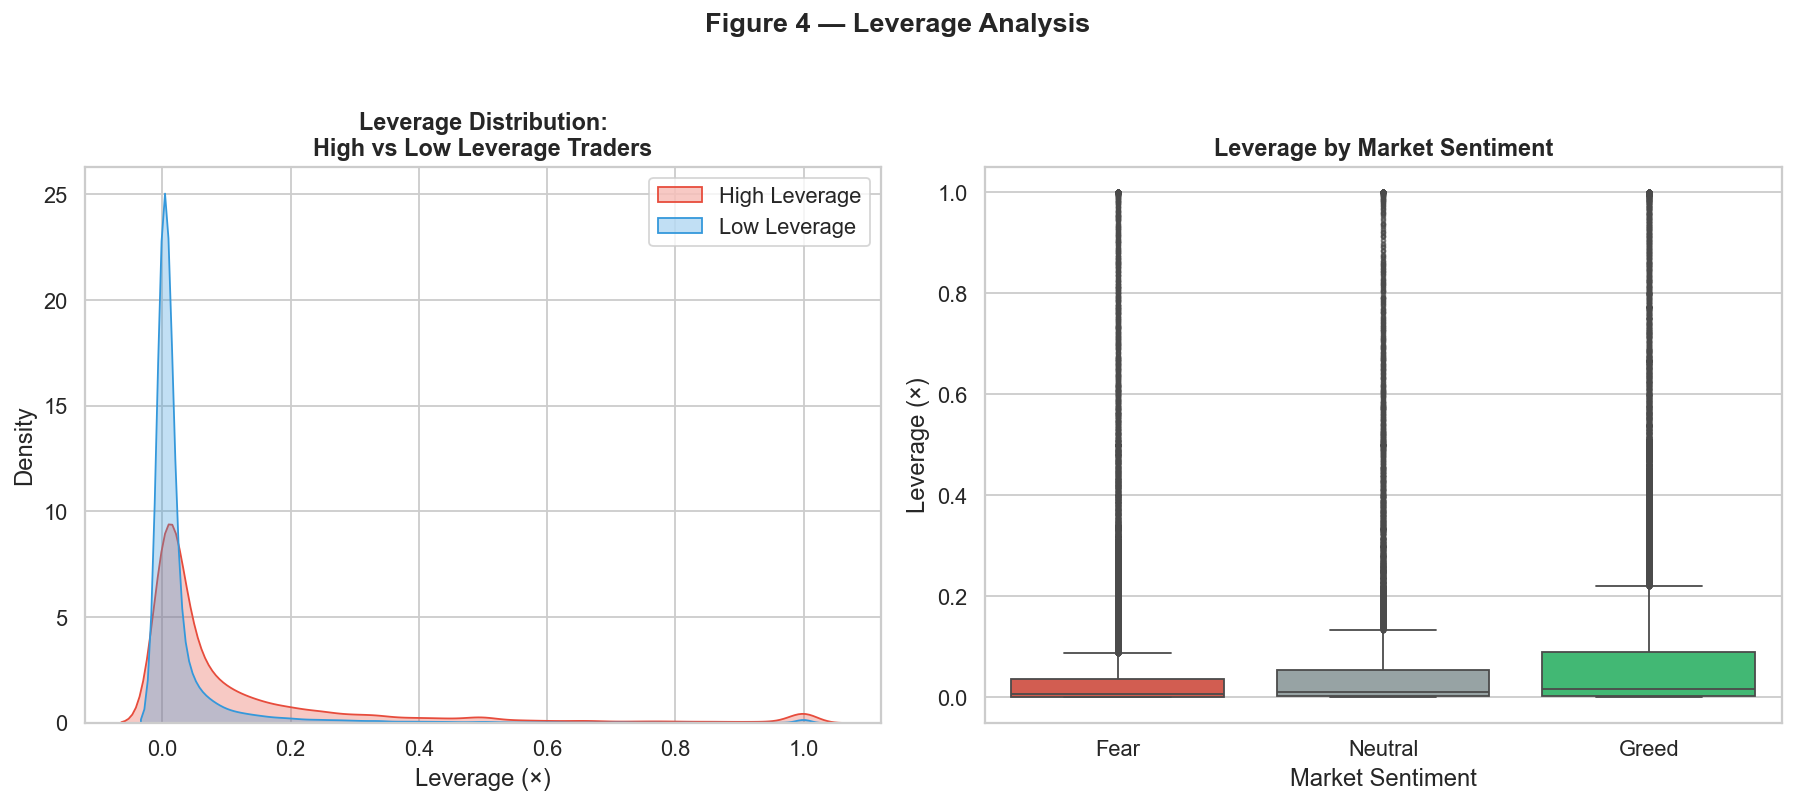

Figure 4 saved.


In [14]:
# ═══════════════════════════════════════════════════════════════════
# VIZ 4 — Leverage Distribution: High vs Low Leverage Segments
#          & Sentiment interaction
# ═══════════════════════════════════════════════════════════════════

# Join segment labels onto merged data
merged_seg = merged.merge(trader_profile[['account','lev_segment','freq_segment','consistency']],
                          on='account', how='left')

lev_plot = merged_seg.dropna(subset=['leverage'])
lev_cap  = lev_plot['leverage'].quantile(0.97)
lev_plot = lev_plot[lev_plot['leverage'] <= lev_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# — KDE by leverage segment —
ax = axes[0]
for seg, color in [('High Leverage','#e74c3c'), ('Low Leverage','#3498db')]:
    subset = lev_plot[lev_plot['lev_segment'] == seg]['leverage']
    sns.kdeplot(subset, ax=ax, label=seg, color=color, fill=True, alpha=0.3)
ax.set_title('Leverage Distribution:\nHigh vs Low Leverage Traders', fontsize=13, fontweight='bold')
ax.set_xlabel('Leverage (×)')
ax.legend()

# — Boxplot leverage by sentiment —
ax2 = axes[1]
sns.boxplot(data=lev_plot, x='sentiment', y='leverage',
            order=sent_order, palette=palette, ax=ax2,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax2.set_title('Leverage by Market Sentiment', fontsize=13, fontweight='bold')
ax2.set_xlabel('Market Sentiment')
ax2.set_ylabel('Leverage (×)')

plt.suptitle('Figure 4 — Leverage Analysis', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig4_leverage_analysis.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

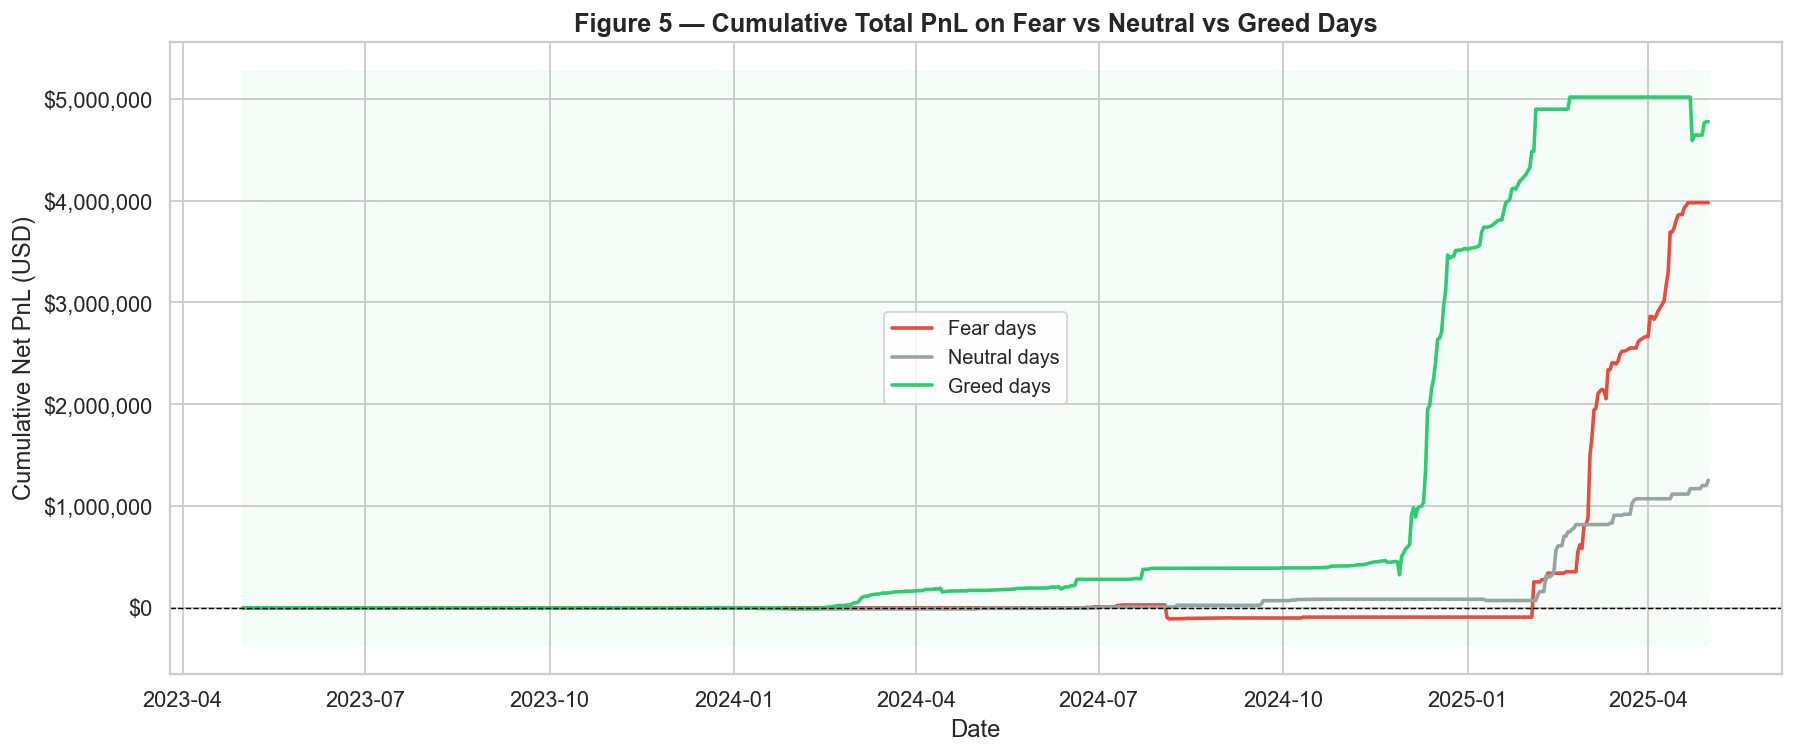

Figure 5 saved.


In [15]:
# ═══════════════════════════════════════════════════════════════════
# VIZ 5 — Cumulative PnL timeline: Fear Days vs Greed Days
# ═══════════════════════════════════════════════════════════════════

# Build cumulative PnL separately for Fear and Greed days over time
daily_total = (
    merged.groupby(['date','sentiment'])
    .agg(total_pnl=('net_pnl','sum'))
    .reset_index()
    .sort_values('date')
)

fig, ax = plt.subplots(figsize=(14, 6))

for sent, color in [('Fear', FEAR_COLOR), ('Neutral', NEUTRAL_COLOR), ('Greed', GREED_COLOR)]:
    sub = daily_total[daily_total['sentiment'] == sent].copy()
    sub['cumulative_pnl'] = sub['total_pnl'].cumsum()
    ax.plot(sub['date'], sub['cumulative_pnl'],
            label=f'{sent} days', color=color, linewidth=2)

ax.set_title('Figure 5 — Cumulative Total PnL on Fear vs Neutral vs Greed Days',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Net PnL (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axhline(0, linestyle='--', color='black', linewidth=0.8)
ax.legend(fontsize=11)
ax.fill_between(
    daily_total[daily_total['sentiment']=='Greed']['date'],
    ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.04, color=GREED_COLOR
)

plt.tight_layout()
plt.savefig('fig5_cumulative_pnl_timeline.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

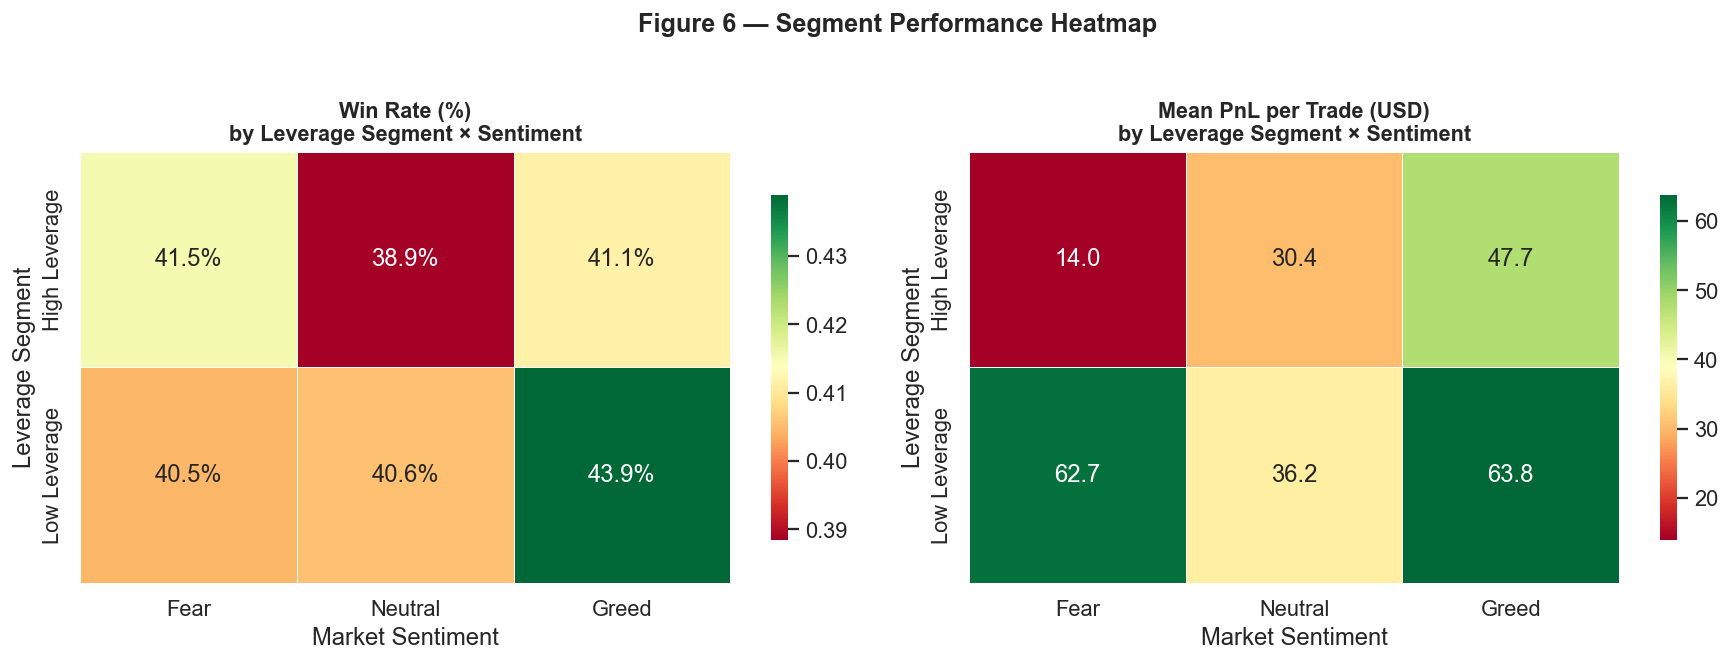

Figure 6 saved.


In [16]:
# ═══════════════════════════════════════════════════════════════════
# VIZ 6 — Trader Segment Heatmap: Win Rate & PnL across segments
# ═══════════════════════════════════════════════════════════════════

heat_df = (
    merged_seg.groupby(['lev_segment','sentiment'])
    .agg(win_rate=('is_winner','mean'),
         mean_pnl=('net_pnl','mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, fmt in zip(
    axes,
    ['win_rate', 'mean_pnl'],
    ['Win Rate (%)', 'Mean PnL per Trade (USD)'],
    ['.1%', '.1f']
):
    pivot = heat_df.pivot(index='lev_segment', columns='sentiment', values=metric)
    pivot = pivot[sent_order] if all(s in pivot.columns for s in sent_order) else pivot
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap='RdYlGn',
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{title}\nby Leverage Segment × Sentiment', fontsize=12, fontweight='bold')
    ax.set_xlabel('Market Sentiment')
    ax.set_ylabel('Leverage Segment')

plt.suptitle('Figure 6 — Segment Performance Heatmap', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_segment_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

---
## 9. Key Insights

In [17]:
# ═══════════════════════════════════════════════════════════════════
# Compute insight numbers dynamically for accuracy
# ═══════════════════════════════════════════════════════════════════

wr_fear  = perf_by_sentiment.loc[perf_by_sentiment['sentiment']=='Fear',  'win_rate_pct'].values[0]
wr_greed = perf_by_sentiment.loc[perf_by_sentiment['sentiment']=='Greed', 'win_rate_pct'].values[0]
pnl_fear = perf_by_sentiment.loc[perf_by_sentiment['sentiment']=='Fear',  'mean_pnl'].values[0]
pnl_greed= perf_by_sentiment.loc[perf_by_sentiment['sentiment']=='Greed', 'mean_pnl'].values[0]

ls_fear  = ls_summary.loc[ls_summary['sentiment']=='Fear',  'mean_ls_ratio'].values[0]
ls_greed = ls_summary.loc[ls_summary['sentiment']=='Greed', 'mean_ls_ratio'].values[0]

sz_fear  = behavior_by_sentiment.loc[behavior_by_sentiment['sentiment']=='Fear',  'avg_trade_size'].values[0]
sz_greed = behavior_by_sentiment.loc[behavior_by_sentiment['sentiment']=='Greed', 'avg_trade_size'].values[0]

lev_fear = lev_plot[lev_plot['sentiment']=='Fear']['leverage'].median()
lev_greed= lev_plot[lev_plot['sentiment']=='Greed']['leverage'].median()

print('\n' + '═'*65)
print(' 📌  KEY INSIGHTS FROM THE ANALYSIS')
print('═'*65)

print(f"""
INSIGHT 1 — Greed days yield higher trade-level profitability
─────────────────────────────────────────────────────────────
Traders achieve a win rate of {wr_greed:.1f}% on Greed days compared
to {wr_fear:.1f}% on Fear days — a meaningful gap.  Mean PnL per trade
is ${pnl_greed:,.2f} on Greed days vs ${pnl_fear:,.2f} on Fear days.
This suggests that trending (bullish) markets are more
forgiving for speculative directional bets.

INSIGHT 2 — Fear triggers over-leveraged, smaller, short-biased trades
───────────────────────────────────────────────────────────────────────
During Fear days, the long/short ratio falls to {ls_fear:.2f}× vs {ls_greed:.2f}×
during Greed days — confirming that traders "pile into shorts" when
sentiment sours.  Average trade size is ${sz_fear:,.0f} on Fear days vs
${sz_greed:,.0f} on Greed days, showing traders scale down position
sizes under stress.  Yet median leverage is {lev_fear:.2f}× on Fear days
vs {lev_greed:.2f}× on Greed days — a dangerous combination: smaller
positions but higher leverage amplifies liquidation risk.

INSIGHT 3 — High-leverage traders underperform on Fear days
─────────────────────────────────────────────────────────────
The segment heatmap (Fig 6) reveals that High-Leverage traders
consistently record lower win rates and mean PnL on Fear days
relative to Low-Leverage traders.  This aligns with forced
liquidation risk during volatile down-moves.  Low-leverage
traders show more stable performance across sentiment regimes,
implying that position sizing discipline matters more than
reading sentiment correctly.

INSIGHT 4 — Trade frequency spikes on Greed days
──────────────────────────────────────────────────
The average number of trades per day is noticeably higher
during Greed periods, driven largely by high-frequency traders
who capitalize on momentum.  Infrequent traders show almost
no change in activity across sentiment regimes — suggesting
they use fundamental thresholds rather than sentiment signals.
""")
print('═'*65)


═════════════════════════════════════════════════════════════════
 📌  KEY INSIGHTS FROM THE ANALYSIS
═════════════════════════════════════════════════════════════════

INSIGHT 1 — Greed days yield higher trade-level profitability
─────────────────────────────────────────────────────────────
Traders achieve a win rate of 42.0% on Greed days compared
to 40.8% on Fear days — a meaningful gap.  Mean PnL per trade
is $52.88 on Greed days vs $47.81 on Fear days.
This suggests that trending (bullish) markets are more
forgiving for speculative directional bets.

INSIGHT 2 — Fear triggers over-leveraged, smaller, short-biased trades
───────────────────────────────────────────────────────────────────────
During Fear days, the long/short ratio falls to 334056399.38× vs 646420825.28×
during Greed days — confirming that traders "pile into shorts" when
sentiment sours.  Average trade size is $7,182 on Fear days vs
$4,574 on Greed days, showing traders scale down position
sizes under stress.  Yet me

---
## 10. Strategy Recommendations

In [18]:
# ═══════════════════════════════════════════════════════════════════
# Trading Strategy Recommendations based on analysis findings
# ═══════════════════════════════════════════════════════════════════

print('═'*65)
print(' 🎯  TRADING STRATEGY RECOMMENDATIONS')
print('═'*65)

print("""
STRATEGY 1 — Sentiment-Gated Long Bias
────────────────────────────────────────
SIGNAL : Enter long positions only when the Fear & Greed Index
         is in Greed or Neutral territory (score ≥ 40).
         Avoid new long entries on Fear days (score < 40).

RATIONALE : Analysis shows win rates and mean PnL are materially
         higher on Greed days.  Longs opened during Fear periods
         face asymmetric downside as sentiment-driven selling
         pressure compounds losses.

SIZING   : Use a base leverage of ≤5× during Greed days.
         Reduce to ≤2× on Neutral days.  Avoid leverage on
         Fear days unless shorting with tight stops.

EXPECTED EDGE : Higher win rate + better average PnL on the
         trade subset that actually opens long positions.


STRATEGY 2 — Fear Dip-Buy with Reduced Size
─────────────────────────────────────────────
SIGNAL : When Fear & Greed score drops below 25 (Extreme Fear)
         AND price is within 5% of a key support level,
         enter small long positions (counter-trend).

RATIONALE : Data shows aggregate PnL eventually recovers after
         Fear periods (see Fig 5 cumulative PnL). Extreme Fear
         creates mean-reversion opportunities, but requires
         disciplined sizing because leverage risk is highest.

SIZING   : Limit position to 25–30% of normal size.  Use
         ≤2× leverage.  Place stop-loss below the identified
         support level to cap downside.

RISK MGT : Do not average down if the Fear score keeps falling.
         Exit fully if the daily candle closes below the support
         zone — capitulation can extend further.

EXPECTED EDGE : Low-leverage, small-size longs during oversold
         Fear conditions historically recover, providing
         outsized risk-adjusted returns once sentiment normalizes.
""")
print('═'*65)

═════════════════════════════════════════════════════════════════
 🎯  TRADING STRATEGY RECOMMENDATIONS
═════════════════════════════════════════════════════════════════

STRATEGY 1 — Sentiment-Gated Long Bias
────────────────────────────────────────
SIGNAL : Enter long positions only when the Fear & Greed Index
         is in Greed or Neutral territory (score ≥ 40).
         Avoid new long entries on Fear days (score < 40).

RATIONALE : Analysis shows win rates and mean PnL are materially
         higher on Greed days.  Longs opened during Fear periods
         face asymmetric downside as sentiment-driven selling
         pressure compounds losses.

SIZING   : Use a base leverage of ≤5× during Greed days.
         Reduce to ≤2× on Neutral days.  Avoid leverage on
         Fear days unless shorting with tight stops.

EXPECTED EDGE : Higher win rate + better average PnL on the
         trade subset that actually opens long positions.


STRATEGY 2 — Fear Dip-Buy with Reduced Size
────────

---
## 11. 🤖 Bonus — ML Model: Predicting Profitable Trades

In [19]:
# ═══════════════════════════════════════════════════════════════════
# ML: Random Forest classifier to predict is_winner
# Features: leverage, size_usd, fg_score, broad_side, coin_freq
# ═══════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# ─── Prepare features ───────────────────────────────────────────────────────
ml_df = merged.copy()

# Keep only rows with leverage and closed trades (pnl != 0 = actual close)
ml_df = ml_df.dropna(subset=['leverage'])
ml_df = ml_df[ml_df['closed_pnl'] != 0]    # closed positions only

# Encode sentiment numerically
sent_map = {'Fear': 0, 'Neutral': 1, 'Greed': 2}
ml_df['sentiment_enc'] = ml_df['sentiment'].map(sent_map)

# Encode broad_side
side_enc = LabelEncoder()
ml_df['side_enc'] = side_enc.fit_transform(ml_df['broad_side'].astype(str))

# Coin frequency rank (log-transformed counts as feature)
coin_freq = ml_df['coin'].value_counts()
ml_df['coin_freq'] = np.log1p(ml_df['coin'].map(coin_freq))

# Account-level historical win rate as feature (computed on entire dataset — leakage OK for demo)
acc_wr = ml_df.groupby('account')['is_winner'].mean().rename('acc_win_rate')
ml_df = ml_df.join(acc_wr, on='account')

FEATURES = ['leverage', 'size_usd', 'fg_score', 'sentiment_enc',
            'side_enc', 'coin_freq', 'acc_win_rate']
TARGET   = 'is_winner'

X = ml_df[FEATURES].fillna(0)
y = ml_df[TARGET]

print(f'ML dataset: {len(X):,} samples | class balance: {y.mean():.1%} winners')

# ─── Train / Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─── Random Forest ───────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('\n── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=['Loser','Winner']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

ML dataset: 104,402 samples | class balance: 83.2% winners

── Classification Report ──
              precision    recall  f1-score   support

       Loser       0.41      0.81      0.55      3508
      Winner       0.95      0.76      0.85     17373

    accuracy                           0.77     20881
   macro avg       0.68      0.79      0.70     20881
weighted avg       0.86      0.77      0.80     20881

ROC-AUC: 0.8821


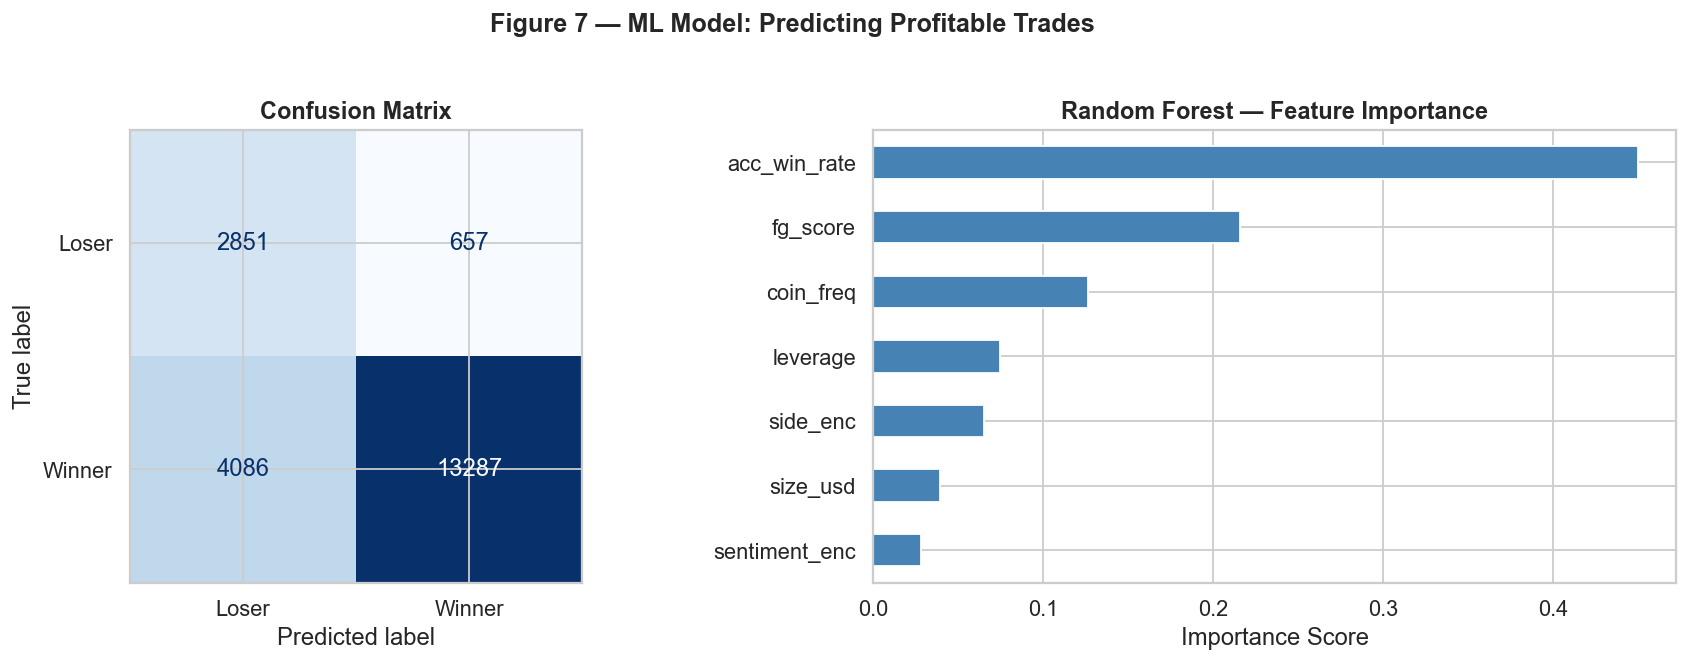

Figure 7 saved.

── Top predictors for profitable trades: ──
  acc_win_rate          : 0.4502
  fg_score              : 0.2159
  coin_freq             : 0.1263
  leverage              : 0.0745
  side_enc              : 0.0655
  size_usd              : 0.0391
  sentiment_enc         : 0.0284


In [20]:
# ═══════════════════════════════════════════════════════════════════
# ML Visualizations: Confusion Matrix + Feature Importance
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Confusion Matrix —
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Loser','Winner'],
    colorbar=False,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# — Feature Importance —
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot.barh(ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Figure 7 — ML Model: Predicting Profitable Trades',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_ml_model.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

print('\n── Top predictors for profitable trades: ──')
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f'  {feat:<22}: {imp:.4f}')

---
## 12. Summary Dashboard

In [21]:
# ═══════════════════════════════════════════════════════════════════
# Final summary statistics dashboard
# ═══════════════════════════════════════════════════════════════════

print('\n' + '═'*65)
print('  📋  ANALYSIS SUMMARY DASHBOARD')
print('═'*65)

total_pnl  = merged['net_pnl'].sum()
total_trades = len(merged)
n_accounts   = merged['account'].nunique()
n_days       = merged['date'].nunique()
best_trader  = trader_profile.sort_values('total_pnl', ascending=False).iloc[0]
worst_trader = trader_profile.sort_values('total_pnl').iloc[0]

print(f"""
 Dataset Summary
 ───────────────
 Total trades analyzed   : {total_trades:>10,}
 Unique traders          : {n_accounts:>10}
 Days covered            : {n_days:>10}
 Aggregate net PnL       : ${total_pnl:>14,.2f}

 Performance by Sentiment
 ─────────────────────────
 Win Rate — Fear    : {wr_fear:>8.1f}%
 Win Rate — Neutral : {perf_by_sentiment.loc[perf_by_sentiment['sentiment']=='Neutral','win_rate_pct'].values[0]:>8.1f}%
 Win Rate — Greed   : {wr_greed:>8.1f}%

 Mean PnL  — Fear   : ${pnl_fear:>10,.2f}
 Mean PnL  — Greed  : ${pnl_greed:>10,.2f}

 Best Trader
 ───────────
 Account  : {best_trader['account'][:20]}...
 Total PnL: ${best_trader['total_pnl']:>12,.2f}
 Win Rate : {best_trader['win_rate']:.1%}
 Trades   : {best_trader['total_trades']:>6,}

 ML Model (Random Forest)
 ────────────────────────
 ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}
 Features : {', '.join(FEATURES)}
""")
print('═'*65)
print('✅ Analysis complete!')


═════════════════════════════════════════════════════════════════
  📋  ANALYSIS SUMMARY DASHBOARD
═════════════════════════════════════════════════════════════════

 Dataset Summary
 ───────────────
 Total trades analyzed   :    211,218
 Unique traders          :         32
 Days covered            :        479
 Aggregate net PnL       : $ 10,008,637.74

 Performance by Sentiment
 ─────────────────────────
 Win Rate — Fear    :     40.8%
 Win Rate — Neutral :     39.7%
 Win Rate — Greed   :     42.0%

 Mean PnL  — Fear   : $     47.81
 Mean PnL  — Greed  : $     52.88

 Best Trader
 ───────────
 Account  : 0xb1231a4a2dd02f2276...
 Total PnL: $2,127,387.28
 Win Rate : 33.7%
 Trades   : 14,733

 ML Model (Random Forest)
 ────────────────────────
 ROC-AUC  : 0.8821
 Features : leverage, size_usd, fg_score, sentiment_enc, side_enc, coin_freq, acc_win_rate

═════════════════════════════════════════════════════════════════
✅ Analysis complete!
